In [3]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt


In [4]:
enrol_files = glob.glob("api_data_aadhar_enrolment*.csv")
bio_files   = glob.glob("api_data_aadhar_biometric*.csv")
demo_files  = glob.glob("api_data_aadhar_demographic*.csv")

print("Enrolment files:", len(enrol_files))
print("Biometric files:", len(bio_files))
print("Demographic files:", len(demo_files))

enroll = pd.concat([pd.read_csv(f) for f in enrol_files], ignore_index=True)
bio    = pd.concat([pd.read_csv(f) for f in bio_files], ignore_index=True)
demo   = pd.concat([pd.read_csv(f) for f in demo_files], ignore_index=True)


Enrolment files: 3
Biometric files: 4
Demographic files: 5


In [5]:
for df in [enroll, bio, demo]:
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    df['year_month'] = df['date'].dt.to_period('M')


In [6]:
enroll_agg = enroll.groupby(
    ['state','district','year_month']
).agg(
    enrol_0_5 = ('age_0_5','sum'),
    enrol_5_17 = ('age_5_17','sum'),
    enrol_18_plus = ('age_18_greater','sum')
).reset_index()

enroll_agg['total_enrol'] = (
    enroll_agg['enrol_0_5'] +
    enroll_agg['enrol_5_17'] +
    enroll_agg['enrol_18_plus']
)


In [7]:
bio_agg = bio.groupby(
    ['state','district','year_month']
).agg(
    bio_5_17 = ('bio_age_5_17','sum'),
    bio_18_plus = ('bio_age_17_','sum')
).reset_index()

bio_agg['total_bio'] = bio_agg['bio_5_17'] + bio_agg['bio_18_plus']


In [8]:
demo_agg = demo.groupby(
    ['state','district','year_month']
).agg(
    demo_5_17 = ('demo_age_5_17','sum'),
    demo_18_plus = ('demo_age_17_','sum')
).reset_index()

demo_agg['total_demo'] = demo_agg['demo_5_17'] + demo_agg['demo_18_plus']


In [9]:
df = enroll_agg.merge(
    bio_agg, on=['state','district','year_month'], how='left'
).merge(
    demo_agg, on=['state','district','year_month'], how='left'
)

df.fillna(0, inplace=True)


In [10]:
df['DUR'] = (df['total_demo'] / df['total_enrol']) * 1000
df['BUI'] = (df['total_bio'] / df['total_enrol']) * 1000

df['CLP'] = (
    (df['bio_5_17'] + df['demo_5_17']) / df['enrol_5_17']
) * 1000

df['MDR'] = (df['total_demo'] + df['total_bio']) / df['total_enrol']

df.replace([np.inf, -np.inf], 0, inplace=True)


In [11]:
metrics = ['DUR','BUI','CLP','MDR']

for m in metrics:
    df[m+'_norm'] = (df[m] - df[m].min()) / (df[m].max() - df[m].min())


In [12]:
df['AUFI'] = df[[m+'_norm' for m in metrics]].mean(axis=1)


In [13]:
df.sort_values('AUFI', ascending=False)[
    ['state','district','year_month','AUFI']
].head(15)


,state,district,year_month,AUFI
2781,Maharashtra,Thane,2025-03,0.892780
1108,Delhi,North West Delhi,2025-03,0.668484
2729,Maharashtra,Pune,2025-04,0.590708
4444,Uttar Pradesh,Gorakhpur,2025-03,0.353390
726,Bihar,Muzaffarpur,2025-03,0.340133
4354,Uttar Pradesh,Bulandshahr,2025-03,0.314186
617,Bihar,Bhagalpur,2025-03,0.306356
753,Bihar,Patna,2025-03,0.296815
3430,Punjab,Amritsar,2025-03,0.286454
1170,Gujarat,Ahmedabad,2025-04,0.240651


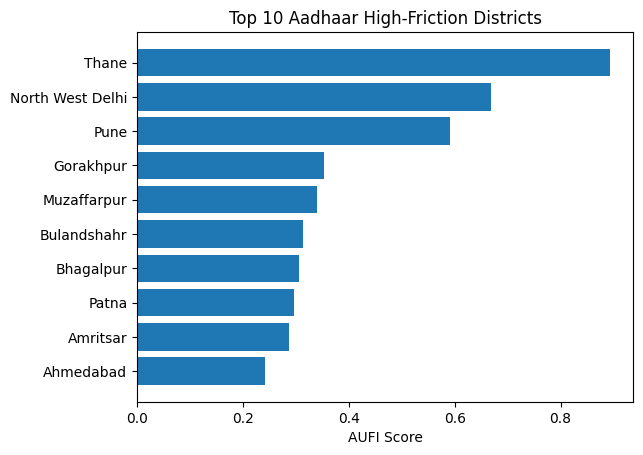

In [14]:
top = df.sort_values('AUFI', ascending=False).head(10)

plt.barh(top['district'], top['AUFI'])
plt.xlabel("AUFI Score")
plt.title("Top 10 Aadhaar High-Friction Districts")
plt.gca().invert_yaxis()
plt.show()
